In [1]:
# ============================================================
# 06_xgboost_tuned.ipynb
# Wellmatch Workforce Analytics — UCL Dissertation 2026
# XGBoost with hyperparameter tuning
# Goal: beat LR baseline of ROC-AUC 0.8226, recall 0.34
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    roc_auc_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from xgboost import XGBClassifier
import shap
import warnings
warnings.filterwarnings('ignore')

print("All imports successful")

All imports successful


In [2]:
# ============================================================
# Section 2 — Load and prepare data
# Identical preprocessing to 05_baseline_model.ipynb
# Ensures fair model comparison
# ============================================================

df = pd.read_csv('../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Drop zero-variance and ID columns
df = df.drop(columns=[
    'EmployeeCount',
    'Over18',
    'StandardHours',
    'EmployeeNumber'
])

# Encode target and OverTime
df['Attrition'] = (df['Attrition'] == 'Yes').astype(int)
df['OverTime'] = (df['OverTime'] == 'Yes').astype(int)

# One-hot encode categoricals
categorical_cols = df.select_dtypes(include='object').columns.tolist()
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Wellbeing composite index — identical to notebook 05
wellbeing_vars = [
    'JobSatisfaction',
    'EnvironmentSatisfaction',
    'RelationshipSatisfaction',
    'WorkLifeBalance'
]
df['WellbeingIndex'] = df[wellbeing_vars].mean(axis=1)

# Train/test split — same random state as notebook 05
X = df.drop(columns=['Attrition'])
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")
print(f"Features:     {X_train.shape[1]}")
print(f"\nBaseline to beat:")
print(f"  ROC-AUC: 0.8226")
print(f"  Recall (leavers): 0.34")

Training set: 1176 rows
Test set:     294 rows
Features:     45

Baseline to beat:
  ROC-AUC: 0.8226
  Recall (leavers): 0.34


In [3]:
# ============================================================
# Section 3 — XGBoost with hyperparameter tuning
# RandomizedSearchCV finds best parameters efficiently
# scale_pos_weight handles class imbalance natively
# ============================================================

# Class imbalance ratio — tells XGBoost to weight leavers higher
# Alternative to SMOTE that XGBoost handles internally
imbalance_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Imbalance ratio: {imbalance_ratio:.2f}")
print(f"This means XGBoost weights leavers {imbalance_ratio:.1f}x more than stayers")

# Define parameter search space
param_grid = {
    'model__n_estimators':    [100, 200, 300, 500],
    'model__max_depth':       [3, 4, 5, 6],
    'model__learning_rate':   [0.01, 0.05, 0.1, 0.2],
    'model__subsample':       [0.6, 0.7, 0.8, 1.0],
    'model__colsample_bytree':[0.6, 0.7, 0.8, 1.0],
    'model__min_child_weight':[1, 3, 5],
    'model__gamma':           [0, 0.1, 0.2, 0.5]
}

# Pipeline with SMOTE + XGBoost
xgb_pipeline = ImbPipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('model', XGBClassifier(
        scale_pos_weight=imbalance_ratio,
        random_state=42,
        eval_metric='auc',
        verbosity=0
    ))
])

# RandomizedSearchCV — tests 50 random combinations
# Faster than GridSearch, finds good parameters efficiently
search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=param_grid,
    n_iter=50,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("\nRunning hyperparameter search — this takes 2-3 minutes...")
search.fit(X_train, y_train)

print(f"\nBest parameters found:")
for param, value in search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest cross-validation AUC: {search.best_score_:.4f}")

Imbalance ratio: 5.19
This means XGBoost weights leavers 5.2x more than stayers

Running hyperparameter search — this takes 2-3 minutes...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters found:
  model__subsample: 0.6
  model__n_estimators: 200
  model__min_child_weight: 1
  model__max_depth: 6
  model__learning_rate: 0.1
  model__gamma: 0.2
  model__colsample_bytree: 1.0

Best cross-validation AUC: 0.8032


XGBOOST RESULTS

ROC-AUC Score: 0.7786

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.89      0.93      0.91       247
        Left       0.53      0.40      0.46        47

    accuracy                           0.85       294
   macro avg       0.71      0.67      0.68       294
weighted avg       0.83      0.85      0.84       294



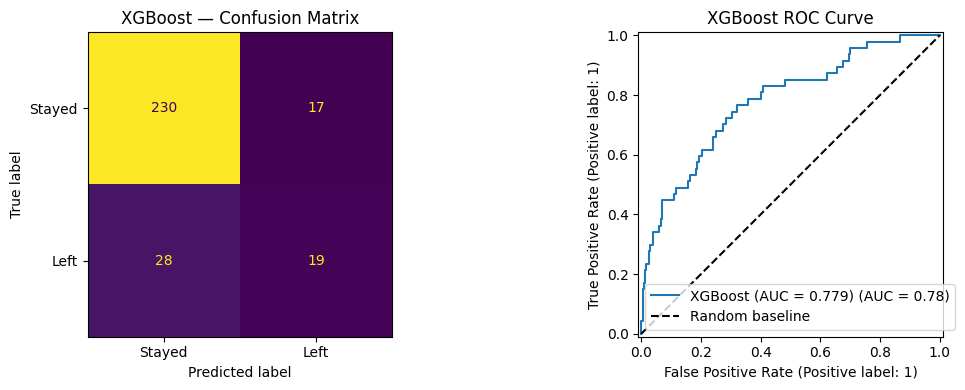

In [4]:
# ============================================================
# Section 4 — Evaluate best XGBoost model on test set
# ============================================================

# Best model from search
best_xgb = search.best_estimator_

# Predict on test set
y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

# Evaluation
xgb_auc = roc_auc_score(y_test, y_prob_xgb)

print("=" * 50)
print("XGBOOST RESULTS")
print("=" * 50)
print(f"\nROC-AUC Score: {xgb_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_xgb,
      target_names=['Stayed', 'Left']))

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb,
    display_labels=['Stayed', 'Left'],
    ax=axes[0],
    colorbar=False
)
axes[0].set_title('XGBoost — Confusion Matrix')

# All three models on same ROC curve
# Load previous probabilities
y_prob_lr = pd.read_csv('../outputs/baseline_results_summary.csv')

RocCurveDisplay.from_predictions(
    y_test, y_prob_xgb,
    ax=axes[1],
    name=f'XGBoost (AUC = {xgb_auc:.3f})'
)
axes[1].plot([0,1], [0,1], 'k--', label='Random baseline')
axes[1].set_title('XGBoost ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/xgb_results.png', dpi=150)
plt.show()